# Validating `video_quality_qc` on a real session

Measures image quality on both cameras of one public session
(`behavior_816212_2025-12-05_13-47-41`, 92 min at 500 Hz, MP4 as transcoded
to the AIND file standard), then shows the report. The MP4s are read over
HTTPS from `s3://aind-open-data`; only the index and the ~100 sampled
keyframes are fetched (about 30 s per camera from a laptop).

What it shows:

1. Over the whole file both cameras are excluded, because the recording
   runs about 8 minutes past the session (the mouse is gone).
2. The task window (first trial start to last trial end) comes from the raw
   asset alone: trial times from the session JSON in `behavior/`, put on
   video frames through the corrected video timing. Over the task, both
   cameras pass every stability check.
3. On the bottom camera the motorized lick spouts move at about 71 min.
   Phase correlation reports this as a 14 px shift even though the camera
   did not move, which is why `shift` is reported but not checked.
4. The same shift in each border strip: on the side camera none moves; on
   the bottom camera the strips are weak, and the spout strip moves.
5. The written outputs (JSON, parquet, batch PDF).

In [1]:
import os
import tempfile
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_dynamic_foraging_behavior_video_analysis import video_quality_qc as vqq
from aind_dynamic_foraging_behavior_video_analysis import video_quality_report as vqr
from aind_dynamic_foraging_behavior_video_analysis.video_alignment import read_trial_times

plt.rcParams["figure.dpi"] = 60  # keep the executed notebook small

SESSION = "behavior_816212_2025-12-05_13-47-41"
ASSET = f"https://aind-open-data.s3.us-west-2.amazonaws.com/{SESSION}"
BASE = f"{ASSET}/behavior-videos"
CAMERAS = {"bottom_camera": f"{BASE}/bottom_camera.mp4",
           "side_camera_right": f"{BASE}/side_camera_right.mp4"}
CACHE = Path(os.environ.get("VQQ_CACHE", "video_quality_qc_data"))


def fetch(key):
    # Local copy of an object in the asset, downloaded once.
    path = CACHE / SESSION / key
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"{ASSET}/{key}", path)
    return path


def cell(row):
    if row["passed"] is None:
        return "skipped"
    return "✓" if row["passed"] else "✗ " + row["message"]


def check_table(results):
    table = pd.DataFrame({
        cam: checks.set_index("check").apply(cell, axis=1)
        for cam, (qc, checks) in results.items()
    })
    table.loc["action"] = {cam: vqq.quality_action(c) for cam, (_, c) in results.items()}
    return table

## 1. Whole file

`measure_video_quality` samples 100 keyframes evenly across the file
(skipping frame 0 and 1% at each end). `check_video_quality` runs each
check; the level checks are skipped because no thresholds exist yet.

In [2]:
whole = {}
for cam, url in CAMERAS.items():
    qc = vqq.measure_video_quality(url)
    whole[cam] = (qc, vqq.check_video_quality(qc, camera=cam))
check_table(whole)

,bottom_camera,side_camera_right
check,,
sharpness_stable,✗ 9 samples in runs off the median by > 30%,✗ 9 samples in runs off the median by > 30%
brightness_stable,✗ 9 samples in runs off the median by > 15%,✗ 8 samples in runs off the median by > 15%
scene_stable,✗ 9 samples in runs correlating < 0.8 with the...,✗ 9 samples in runs correlating < 0.8 with the...
sharp_enough,skipped,skipped
exposure_ok,skipped,skipped
contrast_ok,skipped,skipped
action,exclude: sharpness_stable,exclude: sharpness_stable


The failing samples are the last nine, after about 83 min. The session
card shows why: the rig is empty (last thumbnail, and the outlier frames).
This is not a quality problem, but sampling the whole file cannot tell.

    video_time  sharpness   mean  similarity
91     5006.19     142.46  30.51        0.14
92     5060.19     143.81  30.56        0.13
93     5114.69     143.05  30.61        0.13
94     5169.19     143.20  30.36        0.15
95     5223.69     143.61  29.93        0.15
96     5278.19     143.13  29.94        0.16
97     5332.19     144.03  30.35        0.16
98     5386.69     143.23  30.55        0.16
99     5441.19     142.86  30.27        0.16


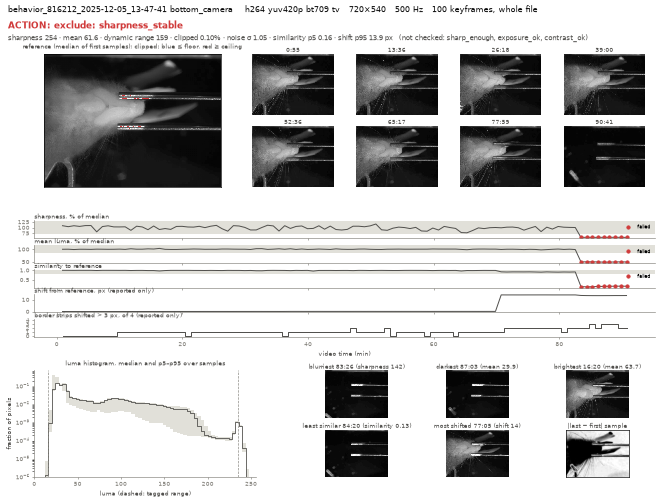

In [3]:
qc, checks = whole["bottom_camera"]
print(qc.samples.loc[checks.set_index("check").loc["scene_stable", "samples"],
                     ["video_time", "sharpness", "mean", "similarity"]].round(2))
fig = vqr.session_card(qc, checks, f"{SESSION} bottom_camera")

## 2. The task only, from the raw asset

No NWB is needed. `read_trial_times` reads trial start, go cue and trial
end from the session JSON in `behavior/` (the same Harp-clock values the
NWB trials table holds; it can read the URL directly). `task_frame_window`
puts the first start and last end on video frames through the corrected
video timing, which needs the camera's CSV (local) and uses the trigger log
if given. Mapping by subtracting the first frame's Harp time instead would
put the task end 315 s late on this session, which dropped 187,024 frames.

In [4]:
behavior_json = f"{ASSET}/behavior/816212_2025-12-05_13-47-41.json"
trials = read_trial_times(behavior_json)
print(len(trials), "trials")
trials.head(3)

506 trials


,start_time,goCue_start_time,stop_time
0,4311.484480,4314.092256,4317.474496
1,4317.514496,4321.107296,4324.423488
2,4324.453504,4328.941376,4332.256480


In [5]:
trigger_log = fetch("behavior/raw.harp/BehaviorEvents/Event_94.bin")
windows = {}
for cam in CAMERAS:
    csv = fetch(f"behavior-videos/{cam}.csv")
    t = time.perf_counter()
    windows[cam] = vqq.task_frame_window(behavior_json, csv, trigger_log)
    start, end = windows[cam]
    print(f"{cam}: frames {start:,}-{end:,} = video {start / 500 / 60:.1f}-{end / 500 / 60:.1f} min "
          f"({time.perf_counter() - t:.1f} s)")

bottom_camera: frames 280,988-2,388,169 = video 9.4-79.6 min (2.6 s)


side_camera_right: frames 281,419-2,389,107 = video 9.4-79.6 min (2.5 s)


The task starts 9.4 minutes into the video (setup before the first
trial) and ends at 79.6 minutes; the empty rig follows from about 83.

In [6]:
task = {}
for cam, url in CAMERAS.items():
    qc = vqq.measure_video_quality(url, frame_window=windows[cam])
    task[cam] = (qc, vqq.check_video_quality(qc, camera=cam))
check_table(task)

,bottom_camera,side_camera_right
check,,
sharpness_stable,✓,✓
brightness_stable,✓,✓
scene_stable,✓,✓
sharp_enough,skipped,skipped
exposure_ok,skipped,skipped
contrast_ok,skipped,skipped
action,use,use


In [7]:
summary = pd.DataFrame({cam: vars(qc.summary) for cam, (qc, _) in task.items()})
summary.loc[["sharpness_med", "sharpness_spread", "mean_med", "mean_spread",
             "dynamic_range_med", "pct_clipped_high_med", "noise_sigma_med",
             "similarity_p5", "shift_p95"]].astype(float).round(3)

,bottom_camera,side_camera_right
sharpness_med,249.277,382.486
sharpness_spread,0.256,0.164
mean_med,61.842,77.834
mean_spread,0.028,0.056
dynamic_range_med,158.000,212.000
pct_clipped_high_med,0.101,1.478
noise_sigma_med,1.049,1.473
similarity_p5,0.909,0.907
shift_p95,13.892,0.609


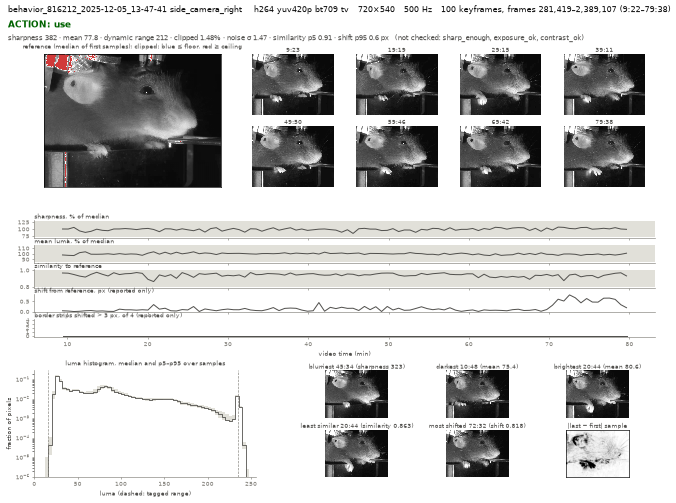

In [8]:
qc, checks = task["side_camera_right"]
fig = vqr.session_card(qc, checks, f"{SESSION} side_camera_right")

## 3. A spout move reads as a camera shift

At about 71 min the bottom camera's `shift` jumps to 14 px and stays. The
overlay of the samples before and after shows that only the lick spouts
moved; the mouse and the rig are still registered. Phase correlation locks
onto the spouts' sharp edges. Tiled estimates split evenly between the two
motions, and correlation with the reference drops about as much for a spout
move (0.91) as for a real 6 px camera bump (0.86–0.90), so no whole-frame
metric separates them. `shift` is therefore reported but not checked;
`scene_stable` still catches gross changes.

,video_time,shift_x,shift_y,similarity
84,4137.69,-0.05,0.05,0.99
85,4180.19,-0.05,0.05,0.99
86,4222.69,-4.78,-9.91,0.91
87,4265.19,-9.68,-9.98,0.91


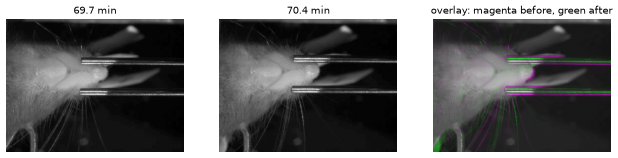

In [9]:
qc, _ = task["bottom_camera"]
s = qc.samples
jump = int(np.argmax(s["shift"].to_numpy() > 5))
before, after = qc.thumbnails[jump - 1] / 255, qc.thumbnails[jump] / 255
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].imshow(before, cmap="gray"); ax[0].set_title(f"{s.video_time[jump - 1] / 60:.1f} min")
ax[1].imshow(after, cmap="gray"); ax[1].set_title(f"{s.video_time[jump] / 60:.1f} min")
ax[2].imshow(np.clip(np.dstack([before, after, before]), 0, 1))
ax[2].set_title("overlay: magenta before, green after")
for a in ax:
    a.axis("off")
s.loc[jump - 2 : jump + 1, ["video_time", "shift_x", "shift_y", "similarity"]].round(2)

## 4. Border strips

The same phase correlation on each 48 px border strip alone, for a survey
of whether cameras ever move (a bump moves every textured strip together).
Reported only. On the side camera no strip moves. On the bottom camera the
strips other than the right one are dark or hold the mouse (low peak, noisy
shifts), and the right strip, which the spouts cross, moves with them.

In [10]:
edge_cols = [f"edge_{e}" for e in vqq.EDGES]
pd.DataFrame({
    cam: pd.concat([qc.samples[edge_cols].max().add_suffix(" max px"),
                    qc.samples[[c + "_peak" for c in edge_cols]].median().add_suffix(" median")])
    for cam, (qc, _) in task.items()
}).round(2)

,bottom_camera,side_camera_right
edge_top max px,2.03,0.12
edge_bottom max px,184.49,0.14
edge_left max px,100.06,0.33
edge_right max px,13.70,1.83
edge_top_peak median,0.07,0.83
edge_bottom_peak median,0.08,0.40
edge_left_peak median,0.04,0.18
edge_right_peak median,0.79,0.38


## 5. Outputs

`write_video_quality` writes the standardized JSON and the per-sample
parquet; `batch_pdf` writes an index, contact sheets and one card per
video, excluded videos first.

In [11]:
out = Path(tempfile.mkdtemp())
for cam, (qc, checks) in task.items():
    json_path, parquet_path = vqq.write_video_quality(qc, checks, out, camera=cam)
print(sorted(p.name for p in out.iterdir()))
print(json_path.read_text()[:600])

['video_quality_bottom_camera.json', 'video_quality_bottom_camera_samples.parquet', 'video_quality_side_camera_right.json', 'video_quality_side_camera_right_samples.parquet']
{
  "camera": "side_camera_right",
  "video_path": "https://aind-open-data.s3.us-west-2.amazonaws.com/behavior_816212_2025-12-05_13-47-41/behavior-videos/side_camera_right.mp4",
  "action": "use",
  "versions": {
    "aind_dynamic_foraging_behavior_video_analysis": "0.1.0",
    "aind_video_utils": "0.7.0"
  },
  "summary": {
    "codec": "h264",
    "pix_fmt": "yuv420p",
    "color_range": "tv",
    "color_transfer": "bt709",
    "bit_depth": 8,
    "width": 720,
    "height": 540,
    "fps": 499.9992725436892,
    "n_frames": 2749302,
    "n_keyframes": 10999,
    "gop": 249.95926902445677,
 


/var/folders/rf/4y0_8n354bn9tqg9pk_zp2900000gn/T/tmpged43_9d/video_quality.pdf 0.5 MB


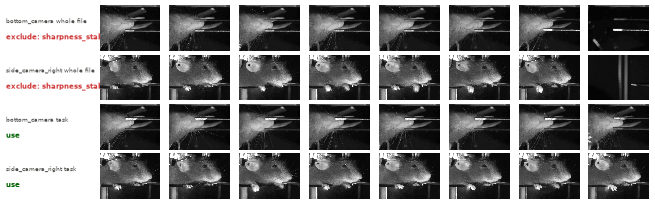

In [12]:
items = [(f"{cam} whole file", *whole[cam]) for cam in CAMERAS]
items += [(f"{cam} task", *task[cam]) for cam in CAMERAS]
pdf = vqr.batch_pdf(items, out / "video_quality.pdf")
print(pdf, f"{pdf.stat().st_size / 1e6:.1f} MB")
fig = vqr.contact_sheet(items)